Accuracy: 82.12 %


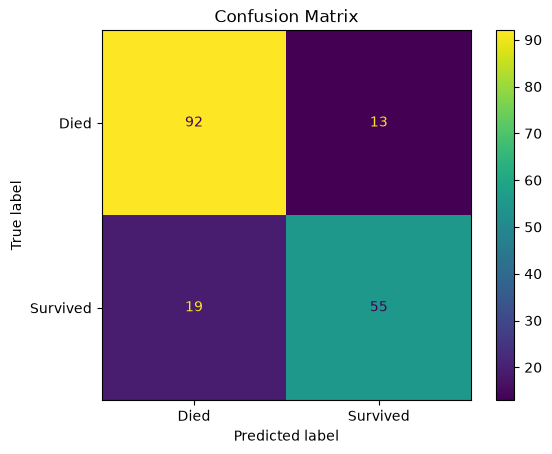

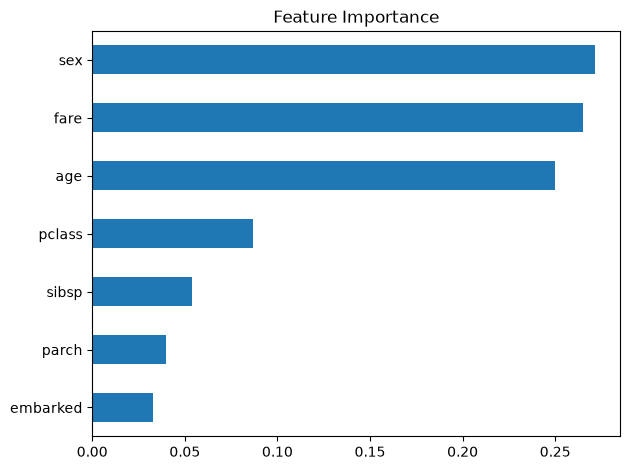

Sample Passenger Prediction: Died


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load data
df = sns.load_dataset('titanic')
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]

# Fill missing
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode text to numbers
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])
le_emb = LabelEncoder()
df['embarked'] = le_emb.fit_transform(df['embarked'])

# Split data
X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Died','Survived']).plot()
plt.title("Confusion Matrix")
plt.show()

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', title='Feature Importance')
plt.tight_layout()
plt.show()

# Sample prediction
sample = pd.DataFrame({
    'pclass':[3], 'sex':[le_sex.transform(['male'])[0]], 'age':[25],
    'sibsp':[0], 'parch':[0], 'fare':[7.25], 'embarked':[le_emb.transform(['S'])[0]]
})
result = "Survived" if model.predict(sample)[0]==1 else "Died"
print("Sample Passenger Prediction:", result)